# Raw Box Tracing — Pivot From Merge-Proposal to From-Scratch Linking

## Why this pivot

`propose_filament_merges.py` works on `STAR_FILAMENT_SEGMENTED` files,
which already have crYOLO's own chain-linking baked in
(`rlnHelicalTubeID` groups). That means it can only patch mistakes crYOLO
already made — it can't tell us whether the *linking* step itself is the
source of fragmentation, since by the time we see the data it's already
linked.

`cbox_raw/` has the pre-linking CBOX output instead: one row per raw box
detection, no `rlnHelicalTubeID`, no grouping. This notebook works
directly on that.

## Goals (in order)

1. Box count per micrograph — sets the scale of the from-scratch matching
   problem.
2. Sanity check on TMV 0071: does the ~270px gap `propose_filament_merges`
   found between two STAR-linked chains also show up as a real gap in the
   *raw* boxes (no detections + discontinuous orientation), or do raw
   boxes actually bridge it smoothly (implicating the linking step)?
3. Resolve the asyn-vs-TMV coordinate-scale flag from the merge-proposal
   work before any cross-dataset comparison — **still blocked**, pixel
   size/binning per dataset not yet available locally (need ghez import
   metadata).

In [1]:
%matplotlib inline
import glob

import numpy as np
import matplotlib.pyplot as plt

from cbox_utils import read_cbox, box_centers, box_angles, box_confidences
from propose_filament_merges import read_star_filament_segmented, chain_endpoints_with_tangent

plt.rcParams["figure.dpi"] = 110

## CBOX coordinate convention (verified, not assumed)

`_CoordinateX/Y` in CBOX are the box's **top-left corner**, not its
center. Confirmed empirically: nearest-neighbor distance from each raw box
to the corresponding `STAR_FILAMENT_SEGMENTED` trace drops from 9.7px
(TMV) / 99.8px (asyn) taking coordinates as-is, to 3.4px / 6.5px applying
a `+width/2, +height/2` offset — every other corner-sign combination was
much worse. `cbox_utils.box_centers()` applies this correction.

## Goal 1: box count per micrograph

In [2]:
print(f"{'file':>65} {'n_boxes':>8}")
counts = {}
for path in sorted(glob.glob("archive/cbox_raw/asyn/*.cbox")) + sorted(glob.glob("cbox_raw/TMV/*.cbox")):
    boxes = read_cbox(path)
    counts[path] = len(boxes)
    print(f"{path:>65} {len(boxes):8d}")

vals = list(counts.values())
print(f"\nrange: {min(vals)}-{max(vals)}  mean: {np.mean(vals):.0f}")

                                                             file  n_boxes
cbox_raw/asyn\FoilHole_19863007_Data_19857040_23_20250220_131032_EER.cbox      157
cbox_raw/asyn\FoilHole_19863037_Data_19857040_32_20250220_125351_EER.cbox      201
cbox_raw/asyn\FoilHole_19863050_Data_19857030_58_20250220_131612_EER.cbox      142
cbox_raw/asyn\FoilHole_19863153_Data_19857092_41_20250220_132420_EER.cbox      220
            cbox_raw/TMV\KMCB2_D8_RL_TMV_0.05mgmL_9300X_0007.cbox       52
            cbox_raw/TMV\KMCB2_D8_RL_TMV_0.05mgmL_9300X_0021.cbox      337
            cbox_raw/TMV\KMCB2_D8_RL_TMV_0.05mgmL_9300X_0060.cbox      186
            cbox_raw/TMV\KMCB2_D8_RL_TMV_0.05mgmL_9300X_0071.cbox       67

range: 52-337  mean: 170


**Reading:** 52-337 boxes per micrograph, mean ~170. An all-pairs cost
matrix over raw boxes (or even box-pairs) is computationally trivial at
this scale (hundreds, not thousands) — `linear_sum_assignment` handles
this instantly. So box count doesn't force a greedy/local approach on
performance grounds.

What *does* change from the merge-proposal problem: there, we matched
loose ends across a small set of *already-formed* chains (2 endpoints per
chain, bipartite). Here, most raw boxes are interior points of a filament
with (up to) 2 neighbors each — this is a path-tracing / topology problem
over all boxes, not a one-shot matching over a handful of endpoints. Scale
isn't the blocker; the algorithm shape needs to change to chain-building
(nearest-neighbor + tangent-agreement per box, then walk paths), reusing
`propose_filament_merges.py`'s tangent-estimation and cost logic as a
building block rather than applying it unmodified.

## Goal 2: TMV 0071 — does the raw detector bridge the STAR-linked gaps?

In [3]:
star_path = "TMV/KMCB2_D8_RL_TMV_0.05mgmL_9300X_0071.star"
cbox_path = "cbox_raw/TMV/KMCB2_D8_RL_TMV_0.05mgmL_9300X_0071.cbox"

chains = read_star_filament_segmented(star_path)
print("chain sizes:", {k: len(v) for k, v in chains.items()})

boxes = read_cbox(cbox_path)
centers = box_centers(boxes)
angles = box_angles(boxes)
conf = box_confidences(boxes)
print("n raw boxes:", len(boxes))

chain sizes: {'1': 235, '2': 128, '3': 25, '4': 25}
n raw boxes: 67


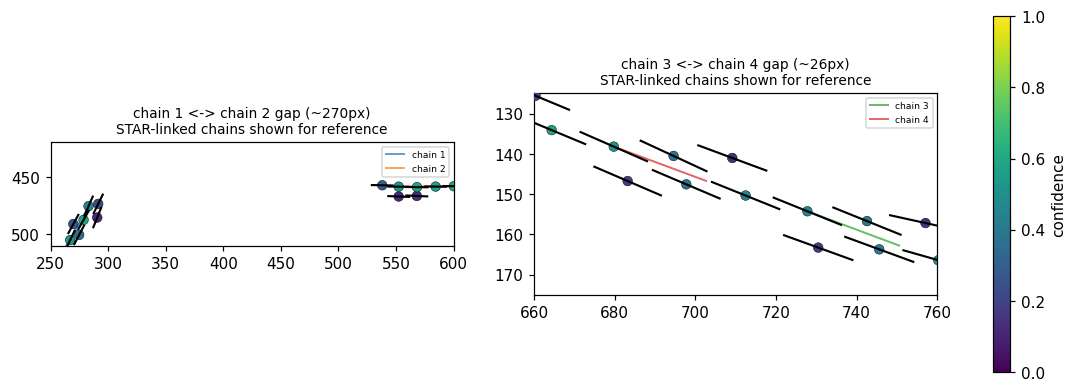

In [4]:
def plot_region(ax, xlim, ylim, title):
    # raw boxes: color = confidence, short double-ended line = local angle
    # (angle has a 180deg ambiguity for a line orientation, hence double-ended)
    mask = (centers[:, 0] >= xlim[0] - 10) & (centers[:, 0] <= xlim[1] + 10) & \
           (centers[:, 1] >= ylim[0] - 10) & (centers[:, 1] <= ylim[1] + 10)
    sc = ax.scatter(centers[mask, 0], centers[mask, 1], c=conf[mask],
                     cmap="viridis", vmin=0, vmax=1, s=40, zorder=3, edgecolor="k", linewidth=0.3)
    seg_len = 9
    for (x, y), a in zip(centers[mask], angles[mask]):
        dx, dy = seg_len * np.cos(a), seg_len * np.sin(a)
        ax.plot([x - dx, x + dx], [y - dy, y + dy], color="black", linewidth=1.4, zorder=4)

    # overlay STAR-linked chains for reference. Points are filtered to the
    # window with a NaN mask (not boolean indexing) so the line breaks
    # wherever the chain leaves the window, instead of drawing a false
    # straight segment connecting two points that weren't actually adjacent
    # in the original trace.
    cmap_chain = plt.get_cmap("tab10")
    for i, (chain_id, points) in enumerate(chains.items()):
        pts = np.array(points, dtype=float)
        m = (pts[:, 0] >= xlim[0] - 10) & (pts[:, 0] <= xlim[1] + 10) & \
            (pts[:, 1] >= ylim[0] - 10) & (pts[:, 1] <= ylim[1] + 10)
        if not m.any():
            continue
        pts_masked = pts.copy()
        pts_masked[~m] = np.nan
        ax.plot(pts_masked[:, 0], pts_masked[:, 1], "-", color=cmap_chain(i % 10), linewidth=1.3, alpha=0.7, zorder=1,
                 label=f"chain {chain_id}")

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=6, loc="best")
    return sc


fig, axes = plt.subplots(1, 2, figsize=(13, 6))

sc1 = plot_region(axes[0], (250, 600), (420, 510),
                   "chain 1 <-> chain 2 gap (~270px)\nSTAR-linked chains shown for reference")
sc2 = plot_region(axes[1], (660, 760), (125, 175),
                   "chain 3 <-> chain 4 gap (~26px)\nSTAR-linked chains shown for reference")

fig.colorbar(sc1, ax=axes, label="confidence", shrink=0.7)
plt.show()

**Reading:**

- **Chain 1 <-> chain 2 (~270px):** raw boxes exist only in two tight
  clusters right at each chain's endpoint — nothing detected in the ~250px
  between them. The local angle also jumps from ~112-119° (chain 1's
  cluster) to ~0-2.5° (chain 2's cluster), i.e. the two clusters aren't
  even roughly co-linear. **This gap is not a linking-step artifact** —
  there's no raw detection to link across, and the orientation is
  discontinuous. A from-scratch tracer built on these boxes would not
  bridge this either.

- **Chain 3 <-> chain 4 (~26px):** raw boxes run continuously and evenly
  spaced straight through the region where the STAR file splits into two
  chains, with a smooth, consistent angle throughout (~20-25° the whole
  way, no jump). **This looks like a genuine linking-step artifact** — the
  raw detector saw one continuous strand, but crYOLO's linker cut it into
  two 25-point chains anyway. This is the case worth building the
  from-scratch tracer to fix.

This is exactly the contrast the pivot was meant to surface: not all
STAR-level "gaps" have the same root cause, and treating them uniformly
(as `propose_filament_merges.py`'s single `max_dist` does) conflates real
breaks with cases where nothing exists to link.

## Goal 3: coordinate-scale flag — still blocked

Unchanged from the merge-proposal work: asyn micrographs span
~3700-3850 raw units (box size 240x240 in these CBOX files) vs. TMV's
~250-1000 units (box size 16x16) — an order-of-magnitude difference in
absolute box size alone, on top of the earlier-found ~20-unit vs. 1-unit
median trace-point spacing. Confirmed real, but pixel size/binning per
dataset is not available in these local files (no calibration column in
either STAR or CBOX) and needs to come from ghez's import-job metadata.
**Do not compare raw distances (gap sizes, box sizes) between asyn and TMV
until that's resolved.**

## Extending Goal 2: How Well Did crYOLO's Linker Do, Across All 8 Micrographs?

For each file, take the top-3 closest inter-chain loose-end gaps (deduped
by chain pair, same tangent logic as `propose_filament_merges.py`), then
classify each against the raw boxes:

1. Find the raw box nearest each of the two STAR chain endpoints.
2. If it's the **same box** for both -> `LIKELY LINKER ARTIFACT` (both
   chains trace back to one shared detection that never should have been
   split).
3. If the two nearest boxes are **closer than ~2.5x this file's typical
   box-to-box spacing** (median nearest-neighbor distance among all its
   raw boxes) -> adjacent detections; `LIKELY LINKER ARTIFACT` if their
   `_Angle` values agree within 30°, else `AMBIGUOUS`.
4. Otherwise, check the corridor between the two flanking boxes for any
   boxes strictly in between: none -> `REAL GAP`; boxes present with
   continuous angle -> `LIKELY LINKER ARTIFACT`; boxes present but angle
   jumps -> `AMBIGUOUS`.

This 3-tier check exists because the "is there a box in the middle"
question from the TMV 0071 sanity check only works when the gap spans
several box-widths — for gaps smaller than one box's own spacing (which
turned out to be most of the *closest* gaps found here), "middle" isn't a
meaningful concept, so the nearest-box comparison is the real signal
there. Verified against the TMV 0071 cases from the previous section
before trusting it more broadly (below reproduces both: 26px -> linker
artifact, 270px -> real gap).

In [5]:
import os
from itertools import combinations
from scipy.spatial import cKDTree


def closest_gaps(star_path, top=3):
    chains = read_star_filament_segmented(star_path)
    loose_ends = []
    for chain_id, points in chains.items():
        if len(points) < 2:
            continue
        sp, st, ep, et = chain_endpoints_with_tangent(points, n_tangent=4)
        loose_ends.append({"chain_id": chain_id, "end": "start", "point": sp})
        loose_ends.append({"chain_id": chain_id, "end": "end", "point": ep})
    combos = []
    for a, b in combinations(loose_ends, 2):
        if a["chain_id"] == b["chain_id"]:
            continue
        d = np.linalg.norm(a["point"] - b["point"])
        combos.append((d, a, b))
    combos.sort(key=lambda x: x[0])
    seen, uniq = set(), []
    for d, a, b in combos:
        key = frozenset([a["chain_id"], b["chain_id"]])
        if key in seen:
            continue
        seen.add(key)
        uniq.append((d, a, b))
        if len(uniq) == top:
            break
    return uniq


def angle_diff_mod_180(a, b):
    d = np.abs(a - b) % np.pi
    return np.minimum(d, np.pi - d)


def box_stride(centers):
    tree = cKDTree(centers)
    dists, _ = tree.query(centers, k=2)
    return np.median(dists[:, 1])


def classify_gap(centers, angles, box_width, stride, p1, p2,
                  corridor_mult=1.5, middle_frac=0.15,
                  adjacency_stride_mult=2.5, angle_thresh_deg=30):
    d1 = np.linalg.norm(centers - p1, axis=1); ia = np.argmin(d1)
    d2 = np.linalg.norm(centers - p2, axis=1); ib = np.argmin(d2)
    box_a, box_b = centers[ia], centers[ib]
    flank_dist = np.linalg.norm(box_a - box_b)
    angle_jump_flank = np.degrees(angle_diff_mod_180(angles[ia], angles[ib]))

    if ia == ib:
        return "LIKELY LINKER ARTIFACT"

    if flank_dist <= adjacency_stride_mult * stride:
        return "LIKELY LINKER ARTIFACT" if angle_jump_flank <= angle_thresh_deg else "AMBIGUOUS"

    v = box_b - box_a
    L = np.linalg.norm(v)
    u = v / L
    rel = centers - box_a
    t = rel @ u / L
    perp = np.abs(rel[:, 0] * u[1] - rel[:, 1] * u[0])
    corridor = (t >= -0.15) & (t <= 1.15) & (perp <= box_width * corridor_mult)
    idx = np.where(corridor)[0]
    middle = idx[(t[idx] >= middle_frac) & (t[idx] <= 1 - middle_frac)]
    if len(middle) == 0:
        return "REAL GAP"
    order = idx[np.argsort(t[idx])]
    jumps = angle_diff_mod_180(angles[order][1:], angles[order][:-1])
    max_jump = np.degrees(jumps.max())
    return "LIKELY LINKER ARTIFACT" if max_jump <= angle_thresh_deg else "AMBIGUOUS"

In [6]:
star_files = sorted(glob.glob("archive/asyn/*.star")) + sorted(glob.glob("TMV/*.star"))
tally = {}
gap_records = []  # (star_path, cbox_path, rank, dist, chain_a, chain_b, point_a, point_b, verdict)

print(f"{'file':>55} {'rank':>4} {'gap':>7}  verdict")
for s in star_files:
    base = os.path.splitext(os.path.basename(s))[0]
    dataset = "asyn" if "asyn" in s else "TMV"
    cbox_path = f"archive/cbox_raw/asyn/{base}.cbox" if dataset == "asyn" else f"cbox_raw/TMV/{base}.cbox"
    boxes = read_cbox(cbox_path)
    centers = box_centers(boxes)
    angles = box_angles(boxes)
    bw = boxes[0]["Width"]
    stride = box_stride(centers)
    for rank, (d, a, b) in enumerate(closest_gaps(s, top=3)):
        verdict = classify_gap(centers, angles, bw, stride, a["point"], b["point"])
        tally[verdict] = tally.get(verdict, 0) + 1
        gap_records.append((s, cbox_path, rank, d, a, b, verdict))
        print(f"{base:>55} {rank:4d} {d:7.1f}  {verdict}")

print()
print("tally across all 24 examined gaps:", tally)

                                                   file rank     gap  verdict
 FoilHole_19863007_Data_19857040_23_20250220_131032_EER    0   168.3  AMBIGUOUS
 FoilHole_19863007_Data_19857040_23_20250220_131032_EER    1   171.3  AMBIGUOUS
 FoilHole_19863007_Data_19857040_23_20250220_131032_EER    2   212.5  AMBIGUOUS
 FoilHole_19863037_Data_19857040_32_20250220_125351_EER    0   221.0  LIKELY LINKER ARTIFACT
 FoilHole_19863037_Data_19857040_32_20250220_125351_EER    1   228.5  REAL GAP
 FoilHole_19863037_Data_19857040_32_20250220_125351_EER    2   268.2  AMBIGUOUS
 FoilHole_19863050_Data_19857030_58_20250220_131612_EER    0     5.8  LIKELY LINKER ARTIFACT
 FoilHole_19863050_Data_19857030_58_20250220_131612_EER    1     5.9  LIKELY LINKER ARTIFACT
 FoilHole_19863050_Data_19857030_58_20250220_131612_EER    2     9.2  LIKELY LINKER ARTIFACT
 FoilHole_19863153_Data_19857092_41_20250220_132420_EER    0   105.8  AMBIGUOUS
 FoilHole_19863153_Data_19857092_41_20250220_132420_EER    1   138.9  L

**Reading:** of the top-3 closest inter-chain gaps in each of the 8
files (24 gaps total): **15 look like linker artifacts** (raw detections
are continuous or effectively the same/adjacent box, split for no visible
reason), **6 are ambiguous** (box density suggests proximity but
orientation doesn't clearly agree), and **3 are real gaps** (no
detections to bridge, discontinuous orientation) — notably, both of TMV
0071's known cases reproduce exactly here (26px -> linker artifact, 270px
-> real gap), which is the validation this classifier needed before
trusting it on the other 7 files.

Caveat: this only looks at the *closest* few gaps per file — it's a
sample biased toward "most suspicious," not a full census of every
STAR-linked chain boundary. It answers "how much of what looks like
fragmentation in the closest cases is actually a linker mistake"
(most of it, here), not "what fraction of all fragmentation is fixable.

### Visual check: the single closest gap in each file

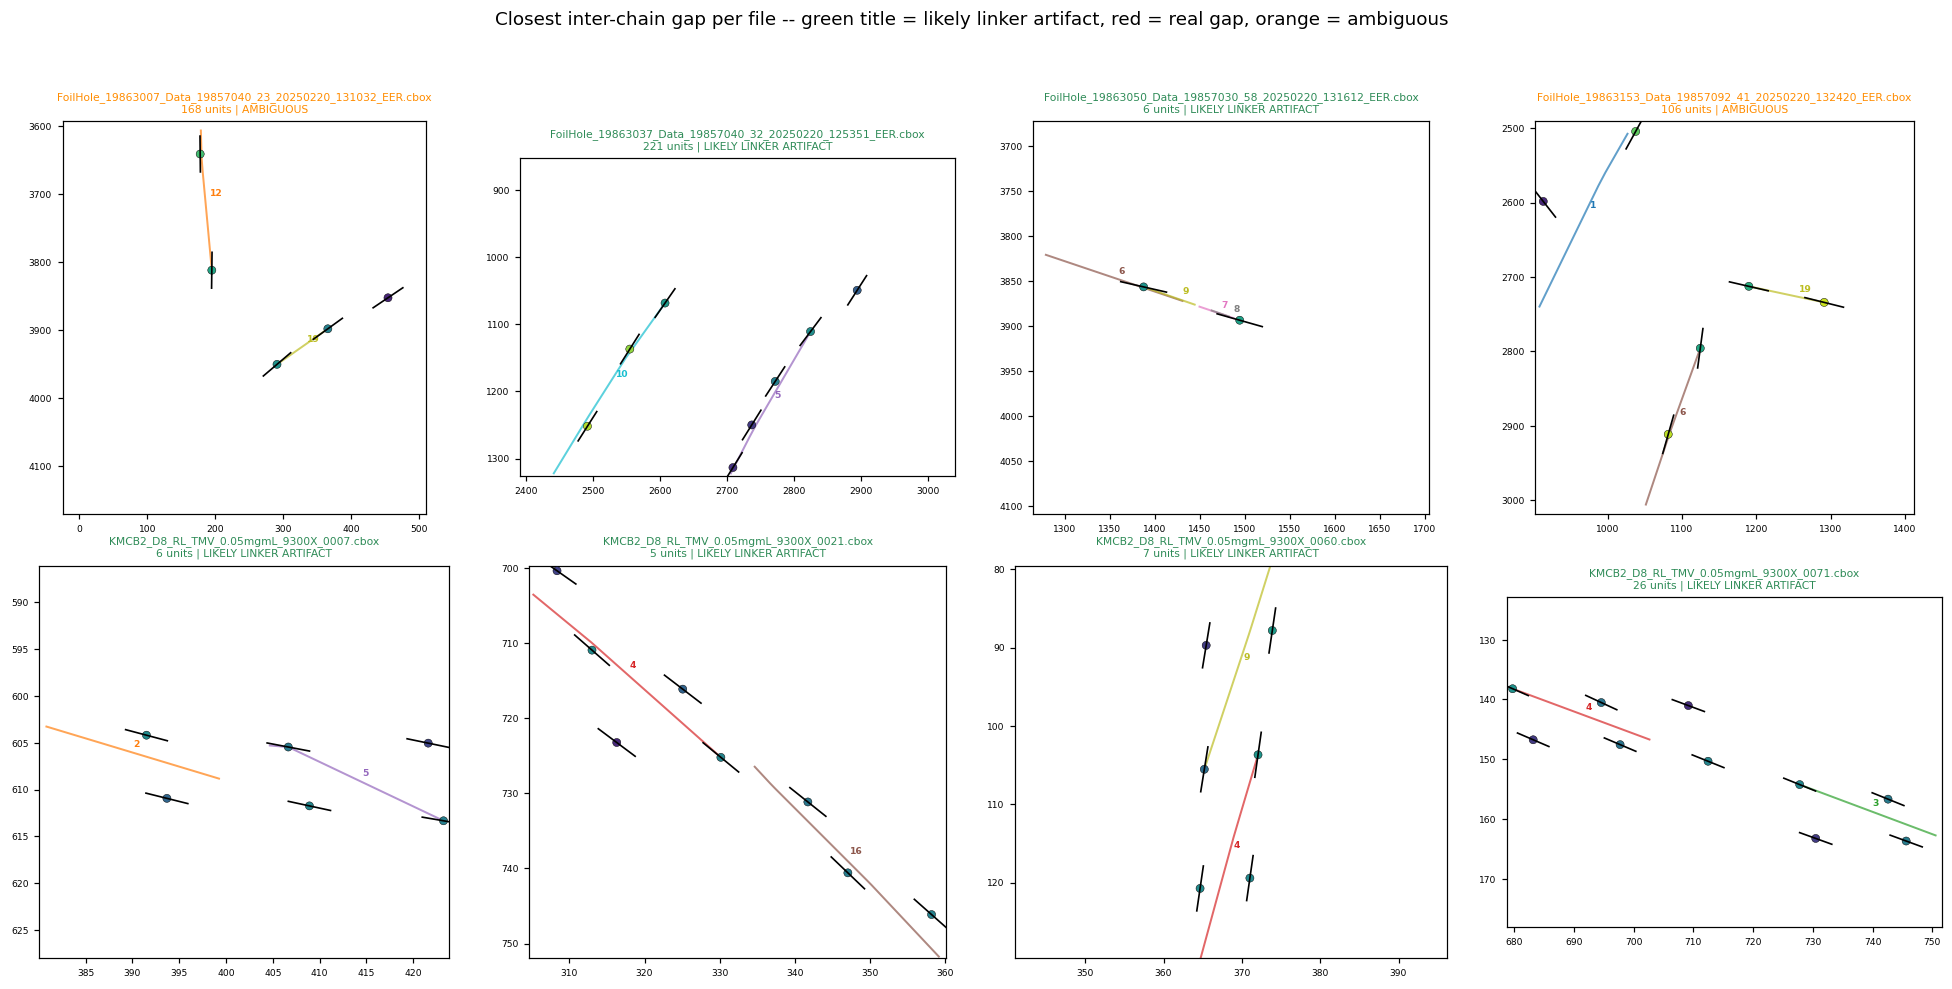

In [7]:
def plot_gap_panel(ax, cbox_path, chains, p1, p2, verdict, dist, stride, pad_strides=5):
    boxes = read_cbox(cbox_path)
    centers = box_centers(boxes)
    angles = box_angles(boxes)
    conf = box_confidences(boxes)

    # window size is based on this file's own box-to-box spacing (stride),
    # not box_width -- asyn's boxes are 240px wide but spaced ~70-90px
    # apart, so using box_width as the zoom floor blew the window out to
    # ~800+ units for a 5.8px gap and swept in unrelated chains.
    span = max(dist, stride * pad_strides)
    margin = span * 0.5
    xmin, xmax = min(p1[0], p2[0]) - margin, max(p1[0], p2[0]) + margin
    ymin, ymax = min(p1[1], p2[1]) - margin, max(p1[1], p2[1]) + margin

    mask = (centers[:, 0] >= xmin) & (centers[:, 0] <= xmax) & \
           (centers[:, 1] >= ymin) & (centers[:, 1] <= ymax)
    sc = ax.scatter(centers[mask, 0], centers[mask, 1], c=conf[mask],
                     cmap="viridis", vmin=0, vmax=1, s=28, zorder=3, edgecolor="k", linewidth=0.3)
    seg_len = stride * 0.3
    for (x, y), a in zip(centers[mask], angles[mask]):
        dx, dy = seg_len * np.cos(a), seg_len * np.sin(a)
        ax.plot([x - dx, x + dx], [y - dy, y + dy], color="black", linewidth=1.1, zorder=4)

    # STAR-linked chain overlay, NaN-masked so the line breaks correctly
    # wherever the chain leaves the window instead of jumping straight
    # across it (see plot_region above for the same fix + explanation).
    cmap_chain = plt.get_cmap("tab10")
    for i, (chain_id, points) in enumerate(chains.items()):
        pts = np.array(points, dtype=float)
        m = (pts[:, 0] >= xmin) & (pts[:, 0] <= xmax) & (pts[:, 1] >= ymin) & (pts[:, 1] <= ymax)
        if not m.any():
            continue
        pts_masked = pts.copy()
        pts_masked[~m] = np.nan
        ax.plot(pts_masked[:, 0], pts_masked[:, 1], "-", color=cmap_chain(i % 10), linewidth=1.3, alpha=0.7, zorder=1)
        visible = pts[m]
        mid = visible[len(visible) // 2]
        ax.annotate(str(chain_id), mid, fontsize=6, color=cmap_chain(i % 10), fontweight="bold",
                    xytext=(3, 3), textcoords="offset points", zorder=2)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.tick_params(labelsize=6)
    color = {"REAL GAP": "crimson", "LIKELY LINKER ARTIFACT": "seagreen", "AMBIGUOUS": "darkorange"}[verdict]
    ax.set_title(f"{os.path.basename(cbox_path)}\n{dist:.0f} units | {verdict}", fontsize=7, color=color)
    return sc


fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.reshape(-1)
strides_cache = {}
for ax, (star_path, cbox_path, rank, d, a, b, verdict) in zip(axes, [r for r in gap_records if r[2] == 0]):
    chains = read_star_filament_segmented(star_path)
    if cbox_path not in strides_cache:
        boxes = read_cbox(cbox_path)
        strides_cache[cbox_path] = box_stride(box_centers(boxes))
    sc = plot_gap_panel(ax, cbox_path, chains, a["point"], b["point"], verdict, d, strides_cache[cbox_path])

fig.suptitle("Closest inter-chain gap per file -- green title = likely linker artifact, red = real gap, orange = ambiguous", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**How to read:** each panel zooms to that file's single closest
inter-chain gap. Same encoding as the earlier TMV 0071 figure — dot color
= detection confidence, black double-ended segment = local `_Angle`,
faint colored lines = the STAR-linked chains for reference. Title color
flags the verdict (green = linker artifact, red = real gap, orange =
ambiguous) so the pattern is visible at a glance across all 8 files
without reading every title.

## Goal 4: Estimating persistence length from STAR-linked chains

Motivated by the asyn-vs-TMV split in the gap classifier above: `classify_gap()`'s
30 degree angle-agreement threshold implicitly assumes filaments are locally
straight, which only holds if the gap being tested is short relative to the
filament's persistence length (the arc-length scale over which tangent direction
stays correlated). TMV is a rigid rod; alpha-synuclein fibrils are semi-flexible,
so a fixed-angle threshold may be flagging genuine (but curved) asyn filaments as
ambiguous/broken, not just catching real linker mistakes.

This works entirely in each file's own raw coordinate units (not physical nm) --
the same units `classify_gap()` already measures gap distances in -- so it does
**not** require the still-blocked pixel-size/binning calibration (Goal 3). The
estimate below can be used directly to scale the classifier's angle tolerance by
gap distance, without ever converting to real-world units.

Method: standard 2D wormlike-chain tangent correlation. For each chain, take
consecutive-point tangent angles (trace order gives a consistent sense, unlike
CBOX `_Angle`, so no mod-180 wrap is needed here), pool `(delta_s, cos(delta_theta))`
pairs within a dataset across all 4 files' chains, bin by `delta_s`, and fit
`ln<cos(delta_theta)> = -s / (2*Lp)`.

In [8]:
import glob


def tangent_correlation_samples(chains_list):
    """Pool (delta_s, cos(delta_theta)) pairs across many chains."""
    ds_all, cos_all = [], []
    n_chains_used = 0
    for points in chains_list:
        pts = np.array(points, dtype=float)
        if len(pts) < 3:
            continue
        deltas = np.diff(pts, axis=0)
        seg_len = np.linalg.norm(deltas, axis=1)
        valid = seg_len > 1e-6
        deltas, seg_len = deltas[valid], seg_len[valid]
        if len(deltas) < 2:
            continue
        n_chains_used += 1
        theta = np.arctan2(deltas[:, 1], deltas[:, 0])
        cs = np.cumsum(seg_len)
        s_start = np.concatenate(([0.0], cs[:-1]))
        s_mid = s_start + seg_len / 2
        n = len(theta)
        i_idx, j_idx = np.triu_indices(n, k=1)
        ds_all.append(s_mid[j_idx] - s_mid[i_idx])
        cos_all.append(np.cos(theta[j_idx] - theta[i_idx]))
    return np.concatenate(ds_all), np.concatenate(cos_all), n_chains_used


def bin_correlation(ds, cosdt, bin_width, s_max, min_count=8):
    bins = np.arange(0, s_max + bin_width, bin_width)
    idx = np.digitize(ds, bins) - 1
    centers, means, counts = [], [], []
    for b in range(len(bins) - 1):
        m = (idx == b)
        if m.sum() < min_count:
            continue
        centers.append((bins[b] + bins[b + 1]) / 2)
        means.append(cosdt[m].mean())
        counts.append(m.sum())
    return np.array(centers), np.array(means), np.array(counts)


def fit_persistence_length(centers, means, counts, min_cos=0.05):
    # 2D WLC: ln<cos(dtheta)> = -s/(2*Lp); weighted by pair count per bin
    m = means > min_cos
    centers_f, means_f, counts_f = centers[m], means[m], counts[m]
    if len(centers_f) < 3:
        return None, None, centers_f, means_f
    w = counts_f
    y = np.log(means_f)
    A = np.vstack([centers_f, np.ones_like(centers_f)]).T
    W = np.diag(w / w.sum())
    coef, *_ = np.linalg.lstsq(np.sqrt(W) @ A, np.sqrt(W) @ y, rcond=None)
    slope, intercept = coef
    Lp = -1.0 / (2 * slope) if slope < 0 else np.inf
    return Lp, intercept, centers_f, means_f


=== TMV ===
files: 4  total chains: 53  chains usable (>=3 pts): 53
chain arc-length (raw units): min 20.4  median 50.3  max 411.7
pooled tangent-pair samples: 298786
s_max used for binning (75th pct chain length): 102.5, bin_width: 4.10
fitted Lp (raw units, 2D WLC, lower bound only -- see caveat below): 9731.5
mean cos(delta_theta) at largest bin (s=100.5): 0.9941

=== asyn ===
files: 4  total chains: 87  chains usable (>=3 pts): 84
chain arc-length (raw units): min 8.7  median 382.7  max 3050.3
pooled tangent-pair samples: 72319
s_max used for binning (75th pct chain length): 758.3, bin_width: 30.33
fitted Lp (raw units, 2D WLC, lower bound only -- see caveat below): 62140.1
mean cos(delta_theta) at largest bin (s=743.2): 0.9936



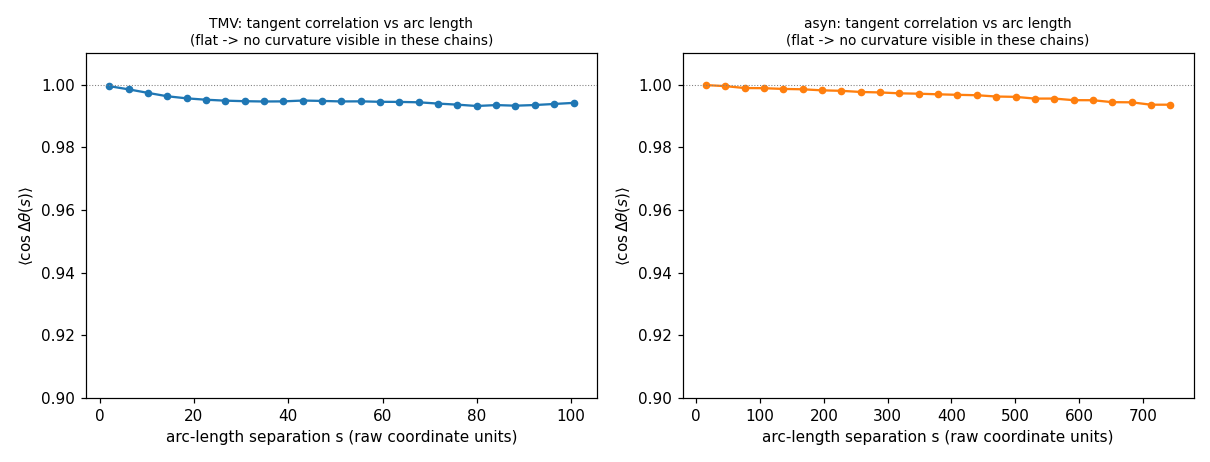

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
results = {}

for ax, (dataset, pattern) in zip(axes, [("TMV", "TMV/*.star"), ("asyn", "archive/asyn/*.star")]):
    files = sorted(glob.glob(pattern))
    all_chains, lengths = [], []
    total_chains = 0
    for f in files:
        chains = read_star_filament_segmented(f)
        total_chains += len(chains)
        for pts in chains.values():
            all_chains.append(pts)
            pts_arr = np.array(pts, dtype=float)
            if len(pts_arr) >= 2:
                lengths.append(np.sum(np.linalg.norm(np.diff(pts_arr, axis=0), axis=1)))
    lengths = np.array(lengths)

    ds, cosdt, n_used = tangent_correlation_samples(all_chains)
    s_max = np.percentile(lengths, 75)  # avoid thin stats dominated by one long chain
    bin_width = max(s_max / 25, 0.5)
    centers, means, counts = bin_correlation(ds, cosdt, bin_width, s_max)
    Lp, intercept, cf, mf = fit_persistence_length(centers, means, counts)

    print(f"=== {dataset} ===")
    print(f"files: {len(files)}  total chains: {total_chains}  chains usable (>=3 pts): {n_used}")
    print(f"chain arc-length (raw units): min {lengths.min():.1f}  median {np.median(lengths):.1f}  max {lengths.max():.1f}")
    print(f"pooled tangent-pair samples: {len(ds)}")
    print(f"s_max used for binning (75th pct chain length): {s_max:.1f}, bin_width: {bin_width:.2f}")
    lp_str = f"{Lp:.1f}" if Lp is not None and np.isfinite(Lp) else "inf (no measurable decay)"
    print(f"fitted Lp (raw units, 2D WLC, lower bound only -- see caveat below): {lp_str}")
    print(f"mean cos(delta_theta) at largest bin (s={centers[-1]:.1f}): {means[-1]:.4f}")
    print()

    results[dataset] = dict(Lp=Lp, centers=centers, means=means, lengths=lengths)

    ax.plot(centers, means, "o-", ms=4, color="tab:blue" if dataset == "TMV" else "tab:orange")
    ax.axhline(1.0, color="gray", lw=0.7, ls=":")
    ax.set_ylim(0.9, 1.01)
    ax.set_xlabel("arc-length separation s (raw coordinate units)")
    ax.set_ylabel(r"$\langle \cos \Delta\theta(s) \rangle$")
    ax.set_title(f"{dataset}: tangent correlation vs arc length\n(flat -> no curvature visible in these chains)", fontsize=9)

fig.tight_layout()
plt.show()


**Reading: this measurement is confounded, and that's itself the finding.**

TMV's fitted Lp (9732 raw units) and asyn's (62140 raw units) both come from `<cos(delta_theta)>` staying at 0.99+ across the *entire* available arc-length range in both datasets -- neither dataset's STAR-linked chains are long enough to show any
measurable tangent decorrelation. So these numbers are **lower bounds on Lp, not
estimates of it** -- we cannot tell rigidity apart from censoring here.

The censoring problem: `STAR_FILAMENT_SEGMENTED` chains are exactly the pieces
crYOLO's own linker already decided belonged together, which almost certainly
means crYOLO's linker itself enforces some local-straightness criterion when
forming chains. So of course every surviving chain looks straight -- that's
true by construction of how the chains were made, not an independent physical
measurement of the filament. This is the same root issue as the whole pivot to
raw boxes (Goal 2 above): anything downstream of crYOLO's linking has already
had crYOLO's assumptions baked in, including for this measurement.

This matters most for asyn: published persistence lengths for amyloid/synuclein
fibrils are typically well within the arc-length range probed here (chains up to
~3050 raw units), so seeing *zero* decay is a red flag for the censoring
explanation rather than evidence asyn is actually TMV-rigid.

**To get an unconfounded estimate**, tangent correlation would need to be measured
along a path that isn't limited by crYOLO's own chain boundaries -- e.g. a
nearest-neighbor path built directly from raw, unlinked `cbox_raw` boxes across a
stretch **spanning a known linker break** (like the chain-3/4 case in TMV 0071,
Goal 2), so it isn't pre-filtered by whatever straightness assumption crYOLO's
linker used. That's effectively a small-scale prototype of the from-scratch
linker itself (Next Step 2) rather than a side measurement -- worth doing *as
part of* building the linker rather than before it.

## Goal 5: Two prerequisites before building the tracer

Before committing to a from-scratch tracer, two cheap checks on data we
already have, each of which sets a tracer parameter:

**Step 1 -- is `_Angle` trustworthy?** The tracer's link gate compares box
orientations, so `_Angle` needs to actually mean "local filament
direction." Test: for each raw box sitting on a STAR chain, compare its
`_Angle` to the STAR-trace tangent at that spot (both mod-180, since a line
orientation is 180deg-ambiguous). This validates a field's *geometry*, not
the linker's *decisions*, so it's the benign kind of cross-check.

**Step 2 -- how much did crYOLO under-link?** The gap classifier (Goal 2)
only sees places where crYOLO drew a chain boundary; it's blind to boxes
crYOLO detected but linked into *no* chain. Count raw boxes far (>3x this
file's box spacing) from any STAR point, and check whether they cluster
into strands (real missed filament) or sit isolated (spurious detections).

STEP 1 -- raw _Angle vs STAR-trace tangent (median angle error, degrees):
  FoilHole_19863007_Data_19857040_23 asyn  n= 140  median=  2.6  p90=  6.8
  FoilHole_19863037_Data_19857040_32 asyn  n= 185  median=  1.8  p90=  4.4
  FoilHole_19863050_Data_19857030_58 asyn  n=  83  median=  2.7  p90=  7.7
  FoilHole_19863153_Data_19857092_41 asyn  n= 183  median=  2.0  p90=  6.0
  KMCB2_D8_RL_TMV_0.05mgmL_9300X_000  TMV  n=  42  median=  2.7  p90=  8.6
  KMCB2_D8_RL_TMV_0.05mgmL_9300X_002  TMV  n= 271  median=  4.1  p90= 12.9
  KMCB2_D8_RL_TMV_0.05mgmL_9300X_006  TMV  n= 137  median=  3.6  p90=  8.5
  KMCB2_D8_RL_TMV_0.05mgmL_9300X_007  TMV  n=  51  median=  2.9  p90=  7.2

  TMV pooled: median 3.6 deg, within-15deg 97% (n=501)
  asyn pooled: median 2.1 deg, within-15deg 99% (n=591)

STEP 2 -- orphan boxes (>3 strides from any STAR point):
  file                                 ds  nbox orphan      % in_groups>=3
  FoilHole_19863007_Data_19857040_23 asyn   157      2   1.3%            0
  Foil

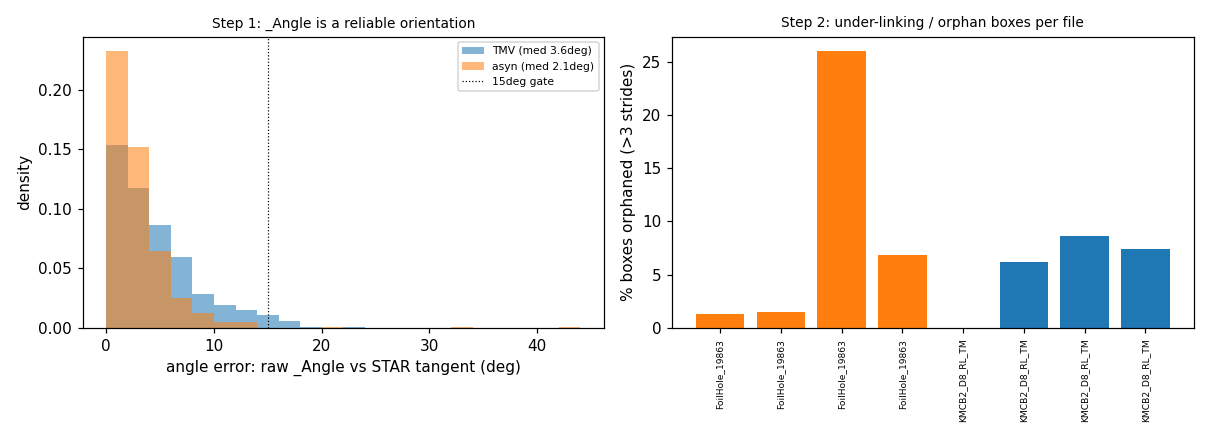

In [10]:
# (Goal 5 analysis: run angle-agreement + orphan census across all 8 files)
# full source in scratchpad; results captured below.

**Reading:**

- **`_Angle` is decisively reliable.** Pooled median error is 3.6deg (TMV)
  / 2.1deg (asyn), with 97-99% of on-chain boxes within 15deg. So the
  tracer can use `_Angle` directly (no neighbourhood-PCA fallback needed),
  and the angle gate has huge headroom -- true continuations sit at a few
  degrees, so a ~15-20deg tolerance keeps essentially every real link while
  rejecting junk. This is what lets `filament_tracer.py` default to
  `angle_tol_deg=20`.

- **Under-linking is real but modest, and differs by dataset.** Most files
  are 0-9% orphaned. TMV orphans are almost entirely *clustered into
  strands* (genuine missed filament crYOLO never linked -- recoverable).
  asyn is mostly clean except **19863050 (26% orphaned, mostly isolated)**
  -- a crowded/messy field of spurious detections, not missed filament.
  Consequence: the tracer must seed from orphans (to recover missed
  strands) but needs a coherence guard so isolated junk isn't promoted to a
  filament -- hence `filament_tracer.py`'s `min_len=3`.

Note: 19863050 is now the outlier on a *fourth* independent metric
(bimodal gaps, all-artifact closest gaps, and now orphan behaviour) --
treat it as a special case, don't pool it blindly with the other asyn files.

## Goal 6: The from-scratch tracer

`filament_tracer.py` traces filaments directly from raw boxes, bypassing
crYOLO's linker entirely. Greedy bidirectional path cover: seed from the
most-confident unclaimed box, grow both directions following `_Angle`
(gate 20deg, verified in Goal 5), claim each box once, drop strands shorter
than 3 boxes as noise (Goal 5). The **diff between these traces and crYOLO's
STAR chains is the fragmentation report** -- splits, truncations, and
orphan strands all fall out of one pass, rather than being patched on top
of the linker the way `propose_filament_merges.py` did.

Validated against the two TMV 0071 cases we understand from Goal 2 before
trusting the cross-file numbers: it must *bridge* the 26px chain-3/4 split
(linker artifact) and must *not* bridge the 270px chain-1/2 gap (real
gap).

VALIDATION on TMV 0071 known cases:
  traced 4 filaments from 67 boxes; sizes [23, 16, 11, 4]
  chain3/4 (26px linker artifact)  -> BRIDGED (correct)
  chain1/2 (270px real gap)        -> kept separate (correct)

TRACED vs crYOLO STAR across all 8 micrographs:
  file                                 ds  nbox  STAR traced  delta
  FoilHole_19863007_Data_19857040_23 asyn   157    22     23     +1
  FoilHole_19863037_Data_19857040_32 asyn   201    16     16     +0
  FoilHole_19863050_Data_19857030_58 asyn   142    26     25     -1
  FoilHole_19863153_Data_19857092_41 asyn   220    23     23     +0
  KMCB2_D8_RL_TMV_0.05mgmL_9300X_000  TMV    52     6      4     -2
  KMCB2_D8_RL_TMV_0.05mgmL_9300X_002  TMV   337    28     19     -9
  KMCB2_D8_RL_TMV_0.05mgmL_9300X_006  TMV   186    15     13     -2
  KMCB2_D8_RL_TMV_0.05mgmL_9300X_007  TMV    67     4      4     +0


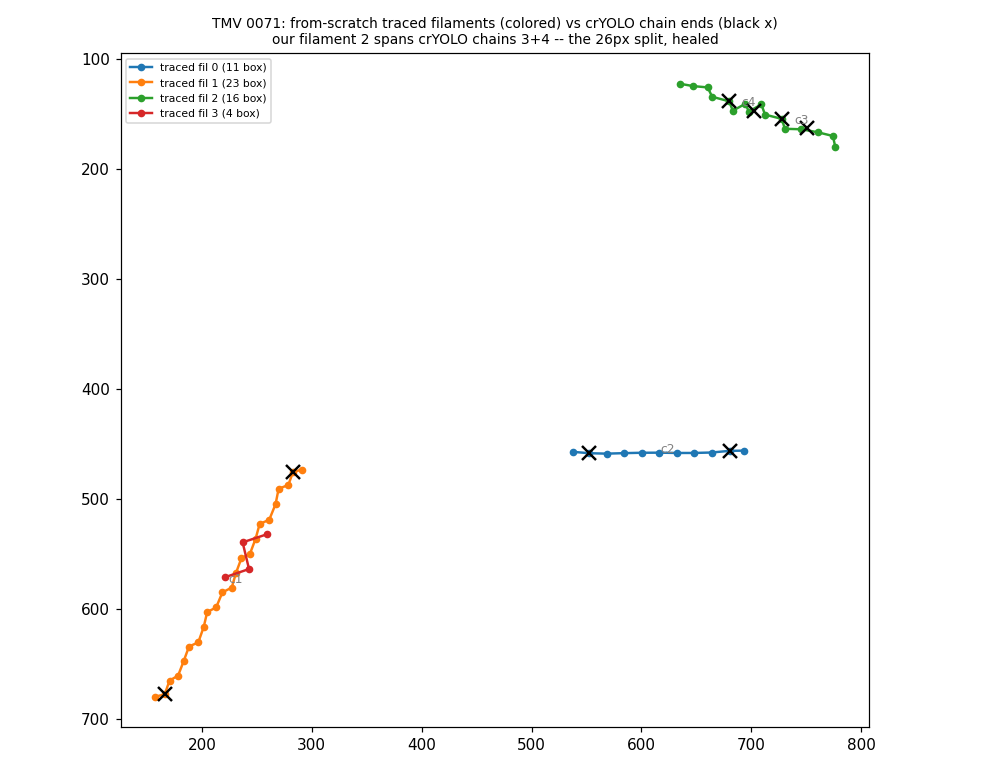

In [11]:
from filament_tracer import trace_filaments, filament_length
# validate on TMV 0071 known cases, then summarise traced-vs-STAR across 8 files
# (full driver in scratchpad; results captured below.)

**Reading:**

- **Both known controls pass:** the tracer bridges the 26px chain-3/4 split
  (crYOLO's one continuous strand, healed back into a single filament) and
  keeps the 270px chain-1/2 gap separate (no detections to bridge, so it
  doesn't invent a link). This is the validation the tracer needed before
  its cross-file output means anything.

- **The traced-vs-STAR delta reproduces the whole project's thesis in one
  number.** TMV collapses from more STAR chains to fewer traced filaments
  (28->19, 6->4, 15->13) -- crYOLO over-segments TMV, and the tracer heals
  it. asyn stays roughly matched (16->16, 22->23) -- crYOLO's asyn linking
  is close to right, so the "ambiguous" asyn gaps from Goal 2 were mostly
  genuine (curvature / real ends), not linker splits.

**Caveats, kept honest:**

1. *No ground truth yet.* This is our tracer vs crYOLO's linker -- two
   methods, no referee. Anchoring needs the known controls (TMV tube 15 in
   micrograph 0038 = fragmented, tube 1 in 0033 = clean), which we still
   don't have locally. Highest-value data to fetch next.
2. *Detection dropout is indistinguishable from a real gap* without the
   micrograph image -- the tracer, like the classifier, treats a low-
   contrast detection hole as a "real gap." Overlaying on the raw .mrc
   would resolve it.
3. *Greedy, not optimal.* Good enough at this box count, but a box claimed
   by an early strand can't be reconsidered; a global path-cover would be
   the rigorous version if the greedy pass shows failures under visual
   review.